In [49]:
import pandas as pd
df = pd.read_csv('/content/train.csv')
df.head()

,date,store,item,sales
0,2013-01-01,1,1,13
1,2013-01-02,1,1,11
2,2013-01-03,1,1,14
3,2013-01-04,1,1,13
4,2013-01-05,1,1,10


In [50]:
df.shape

(913000, 4)

In [51]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 913000 entries, 0 to 912999
Data columns (total 4 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   date    913000 non-null  object
 1   store   913000 non-null  int64 
 2   item    913000 non-null  int64 
 3   sales   913000 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 27.9+ MB


In [52]:
df.describe()

,store,item,sales
count,913000.000000,913000.000000,913000.000000
mean,5.500000,25.500000,52.250287
std,2.872283,14.430878,28.801144
min,1.000000,1.000000,0.000000
25%,3.000000,13.000000,30.000000
50%,5.500000,25.500000,47.000000
75%,8.000000,38.000000,70.000000
max,10.000000,50.000000,231.000000


In [53]:
df['store'].nunique()

10

In [54]:
df['item'].nunique()

50

In [55]:
df.isnull().sum()

,0
date,0
store,0
item,0
sales,0


In [56]:
df['date'] = pd.to_datetime(df['date'])

In [57]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 913000 entries, 0 to 912999
Data columns (total 4 columns):
 #   Column  Non-Null Count   Dtype         
---  ------  --------------   -----         
 0   date    913000 non-null  datetime64[ns]
 1   store   913000 non-null  int64         
 2   item    913000 non-null  int64         
 3   sales   913000 non-null  int64         
dtypes: datetime64[ns](1), int64(3)
memory usage: 27.9 MB


In [58]:
df['month'] = df['date'].dt.month

In [59]:
df.head()

,date,store,item,sales,month
0,2013-01-01,1,1,13,1
1,2013-01-02,1,1,11,1
2,2013-01-03,1,1,14,1
3,2013-01-04,1,1,13,1
4,2013-01-05,1,1,10,1


In [60]:
import matplotlib.pyplot as plt

In [61]:
monthly_sales = df.groupby('month')['sales'].sum()

In [62]:
monthly_sales

,sales
month,
1,2753149
2,2776177
3,3666182
4,4136467
5,4582437
6,4726911
7,5192393
8,4580655
9,4130457


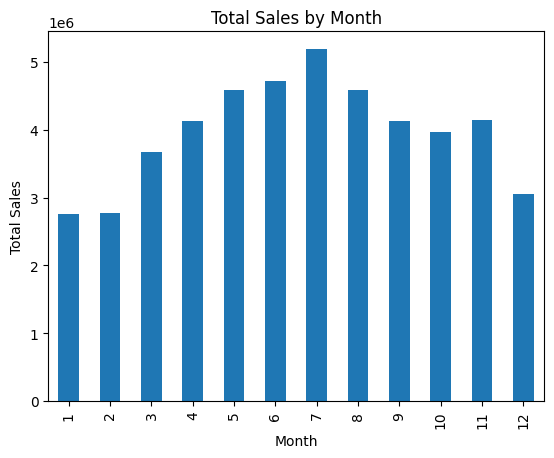

In [63]:
monthly_sales.plot(kind='bar', title='Total Sales by Month')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.show()

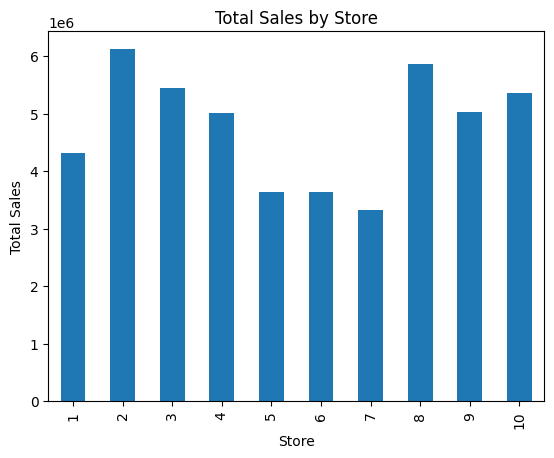

In [64]:
sales_by_store = df.groupby('store')['sales'].sum()
sales_by_store.plot(kind='bar', title='Total Sales by Store')
plt.xlabel('Store')
plt.ylabel('Total Sales')
plt.show()

# In the month of july, the total sales are the highest while the total sales are the least in the months of january and february.

So the sales accross 10 stores are different but not entirely. while some has the highest saled some of the store has less compararatively.

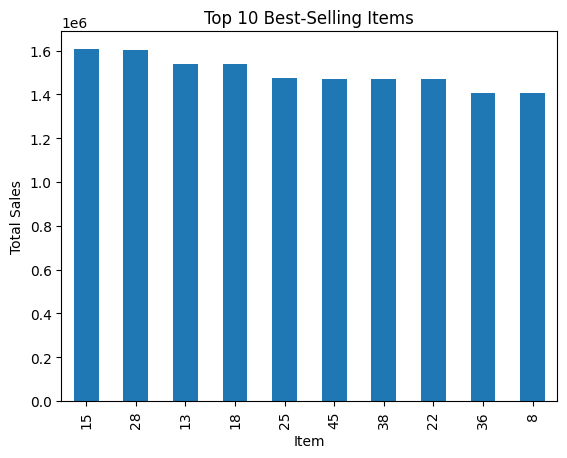

In [65]:
sales_by_item = df.groupby('item')['sales'].sum().sort_values(ascending=False)
sales_by_item.head(10).plot(kind='bar', title='Top 10 Best-Selling Items')
plt.xlabel('Item')
plt.ylabel('Total Sales')
plt.show()

this is a chart showing the top 10 best selling items.
# New Section

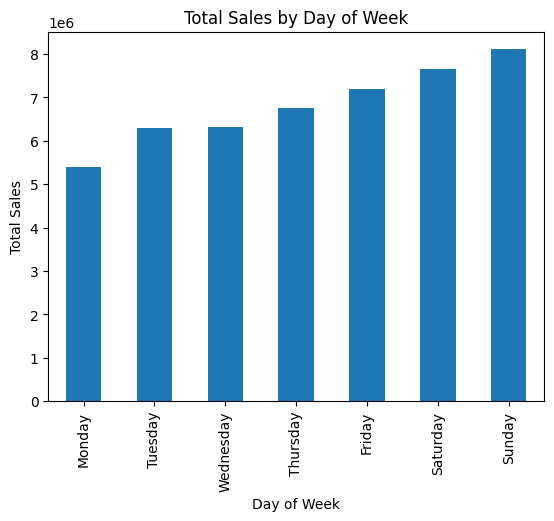

In [66]:
df['weekday'] = df['date'].dt.day_name()
weekday_sales = df.groupby('weekday')['sales'].sum()
weekday_sales = weekday_sales.reindex(['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'])
weekday_sales.plot(kind='bar', title='Total Sales by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Total Sales')
plt.show()

# this chart shows that theres is a very good difference during the weekend as the sales are higher during the weekend compared to the weekdays.

**Summary of Findings**

therefore we can summarise the fact that sales are different accross different stores and there isn't a particular product which is high on demand it depends on the time. Also the sales are higher on weekends comparing to the weekdays

In [67]:
train = df[df['date'] < '2017-10-01']
test = df[df['date'] >= '2017-10-01']
print(train.shape)
print(test.shape)

(867000, 6)
(46000, 6)


In [68]:
store_item_avg = train.groupby(['store','item'])['sales'].mean().reset_index()
store_item_avg = store_item_avg.rename(columns={'sales':'baseline_pred'})
store_item_avg.head()

,store,item,baseline_pred
0,1,1,19.957901
1,1,2,52.978662
2,1,3,33.165513
3,1,4,19.931949
4,1,5,16.585352


In [69]:
test = test.merge(store_item_avg, on=['store','item'], how='left')
test.head()

,date,store,item,sales,month,weekday,baseline_pred
0,2017-10-01,1,1,21,10,Sunday,19.957901
1,2017-10-02,1,1,12,10,Monday,19.957901
2,2017-10-03,1,1,18,10,Tuesday,19.957901
3,2017-10-04,1,1,15,10,Wednesday,19.957901
4,2017-10-05,1,1,20,10,Thursday,19.957901


In [70]:
test['error'] = abs(test['sales'] - test['baseline_pred'])
mae = test['error'].mean()
print('Mean Absolute Error:', mae)

Mean Absolute Error: 10.192685522290759


'Baseline Model: predicting each store-item's historical average, the Mean Absolute Error is 10.19 units per day, roughly 19.5% of average daily sales (52 units). This is the benchmark any more advanced model must beat.'

In [71]:
monthly_avg = train.groupby(['store','item','month'])['sales'].mean().reset_index()
monthly_avg = monthly_avg.rename(columns={'sales':'seasonal_pred'})
monthly_avg.head()

,store,item,month,seasonal_pred
0,1,1,1,13.709677
1,1,1,2,14.631206
2,1,1,3,17.600000
3,1,1,4,20.786667
4,1,1,5,22.245161


In [72]:
test = test.merge(monthly_avg, on=['store','item','month'], how='left')
test.head()

,date,store,item,sales,month,weekday,baseline_pred,error,seasonal_pred
0,2017-10-01,1,1,21,10,Sunday,19.957901,1.042099,19.233871
1,2017-10-02,1,1,12,10,Monday,19.957901,7.957901,19.233871
2,2017-10-03,1,1,18,10,Tuesday,19.957901,1.957901,19.233871
3,2017-10-04,1,1,15,10,Wednesday,19.957901,4.957901,19.233871
4,2017-10-05,1,1,20,10,Thursday,19.957901,0.042099,19.233871


In [73]:
test['seasonal_error'] = abs(test['sales'] - test['seasonal_pred'])
seasonal_mae = test['seasonal_error'].mean()
print('Baseline MAE:', mae)
print('Seasonal Model MAE:', seasonal_mae)

Baseline MAE: 10.192685522290759
Seasonal Model MAE: 10.146162716222534


In [74]:
test['weekday'] = test['date'].dt.day_name()
weekday_avg = train.copy()
weekday_avg['weekday'] = weekday_avg['date'].dt.day_name()
weekday_avg = weekday_avg.groupby(['store','item','month','weekday'])['sales'].mean().reset_index()
weekday_avg = weekday_avg.rename(columns={'sales':'full_pred'})

In [75]:
test = test.merge(weekday_avg, on=['store','item','month','weekday'], how='left')
test['full_error'] = abs(test['sales'] - test['full_pred'])
full_mae = test['full_error'].mean()
print('Baseline MAE:', mae)
print('Seasonal (month) MAE:', seasonal_mae)
print('Seasonal + Weekday MAE:', full_mae)

Baseline MAE: 10.192685522290759
Seasonal (month) MAE: 10.146162716222534
Seasonal + Weekday MAE: 8.824497199881097


In [76]:
df['date'] = pd.to_datetime(df['date'], errors='coerce')

In [77]:
 df['date'].isnull().sum()

np.int64(0)

In [78]:
df = df.dropna(subset=['date'])
df.shape

(913000, 6)

In [79]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

In [80]:
train['weekday_num'] = train['date'].dt.weekday
test['weekday_num'] = test['date'].dt.weekday

In [81]:
features = ['store', 'item', 'month', 'weekday_num']
X_train = train[features]
y_train = train['sales']
X_test = test[features]
y_test = test['sales']

In [82]:
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [83]:
predictions = model.predict(X_test)
rf_mae = mean_absolute_error(y_test, predictions)
print('Baseline MAE:', mae)
print('Seasonal (month) MAE:', seasonal_mae)
print('Seasonal + Weekday MAE:', full_mae)
print('Random Forest MAE:', rf_mae)

Baseline MAE: 10.192685522290759
Seasonal (month) MAE: 10.146162716222534
Seasonal + Weekday MAE: 8.824497199881097
Random Forest MAE: 8.826385721681365


In [84]:
train = train.sort_values(['store', 'item', 'date'])
train['sales_lag_7'] = train.groupby(['store', 'item'])['sales'].shift(7)

test = test.sort_values(['store', 'item', 'date'])
test['sales_lag_7'] = test.groupby(['store', 'item'])['sales'].shift(7)

In [85]:
print('Train missing lag values:', train['sales_lag_7'].isnull().sum())
print('Test missing lag values:', test['sales_lag_7'].isnull().sum())

Train missing lag values: 3500
Test missing lag values: 3500


In [86]:
train = train.dropna(subset=['sales_lag_7'])
test = test.dropna(subset=['sales_lag_7'])
print(train.shape)
print(test.shape)

(863500, 8)
(42500, 14)


In [87]:
features = ['store', 'item', 'month', 'weekday_num', 'sales_lag_7']
X_train = train[features]
y_train = train['sales']
X_test = test[features]
y_test = test['sales']

model2 = RandomForestRegressor(n_estimators=100, random_state=42)
model2.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [88]:
predictions2 = model2.predict(X_test)
rf2_mae = mean_absolute_error(y_test, predictions2)
print('Baseline MAE:', mae)
print('Seasonal + Weekday MAE:', full_mae)
print('Random Forest (no lag) MAE:', rf_mae)
print('Random Forest + Lag MAE:', rf2_mae)

Baseline MAE: 10.192685522290759
Seasonal + Weekday MAE: 8.824497199881097
Random Forest (no lag) MAE: 8.826385721681365
Random Forest + Lag MAE: 8.169583707095518


In [89]:
importance = pd.Series(model2.feature_importances_, index=features).sort_values(ascending=False)
print(importance)

sales_lag_7    0.889784
item           0.037422
month          0.024919
store          0.024118
weekday_num    0.023757
dtype: float64


## Conclusion

**Problem:** Retailers need to forecast daily product demand at the store-item level to avoid stockouts (lost sales) and overstock (wasted inventory/capital).

**Data:** 913,000 daily sales records across 10 stores and 50 items, spanning 5 years (2013–2017), sourced from Kaggle's Store Item Demand Forecasting Challenge. The dataset was complete, with no missing values after removing negligible parsing artifacts.

**Key findings from exploratory analysis:**
- Sales show strong monthly seasonality, roughly doubling from a January low (2.75M units) to a July peak (5.19M units).
- Sales climb steadily across the week, from a Monday low (5.4M) to a Sunday peak (8.2M) — a ~50% swing, driven by day-of-week rather than sudden weekend spikes.
- Total sales vary meaningfully by store, with the top store outselling the lowest by roughly 2x.
- Demand across top-selling items is relatively evenly spread, with no single dominant product.

**Modeling approach and results:**
| Model | Mean Absolute Error |
|---|---|
| Naive baseline (historical average per store-item) | 10.19 |
| + Month (seasonality) | 10.15 |
| + Weekday | 8.82 |
| Random Forest (same features) | 8.83 |
| Random Forest + 7-day sales lag | **8.17** |

Adding a 7-day sales lag feature (actual sales from the same store-item exactly one week prior) improved forecast accuracy by ~20% over the naive baseline, and ~7% over the best grouped-average approach.

**Key insight:** Feature importance analysis showed that recent sales history (`sales_lag_7`) accounted for ~89% of the model's predictive power — far outweighing calendar features like month, weekday, store, or item. This suggests that for short-term demand forecasting, recent actual sales trends are a stronger signal than seasonal or calendar patterns.

**Business recommendation:** Inventory and staffing decisions should weight recent sales trends more heavily than seasonal calendars, particularly for fast-moving items where week-to-week demand shifts quickly.

**Limitations:** This analysis used only internal sales history. It does not account for external factors such as promotions, holidays, pricing changes, weather, or competitor activity, all of which likely influence real-world demand and could improve accuracy further if available.